In [119]:
%autoreload 2

In [118]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import gridspec, rcParams
from datetime import datetime as dt, timedelta
import pingouin as pg
import scipy.stats as stats
from fish import Gafftopsail
sys.path.append(r'/Users/zichenhe/miniforge3/envs/naumann_lab/2ptank/')#(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = ('/Users/zichenhe/Desktop/fishes/Imaging/251224_overlap/fish2/')
rcParams['font.size'] = 4  

In [3]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging'], sequence = 5)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]

__EACH STIM__

In [120]:
#axis 0: trial; axis 1: neuron; axis 2: frame
#from stationary start to duration + 20
f_pertrial_dict = barcode.get_pertrial_f(fish)

getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s


In [6]:
stim_list = ['dot_l', 'dot_r', 'forward', str(['dot_l', 'forward']), str(['dot_r', 'forward']),
            'left', str(['dot_l', 'left']), str(['dot_r', 'left']),
             'right', str(['dot_l', 'right']), str(['dot_r', 'right']),
             'backward', str(['dot_l', 'backward']), str(['dot_r', 'backward'])]

__get visually responsive cells__

In [206]:
barred_dot_neurons = barcode.select_dotbarcode(fish, f_pertrial_dict, baseline_s = 10, response_s = 5)
vis_neurons = barcode.select_visbarcode(fish, f_pertrial_dict, baseline_s = 10, response_s =30, perc_trial_threshold = 0.8)

selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5
selection criteria: max >= baseline mean * 0.5


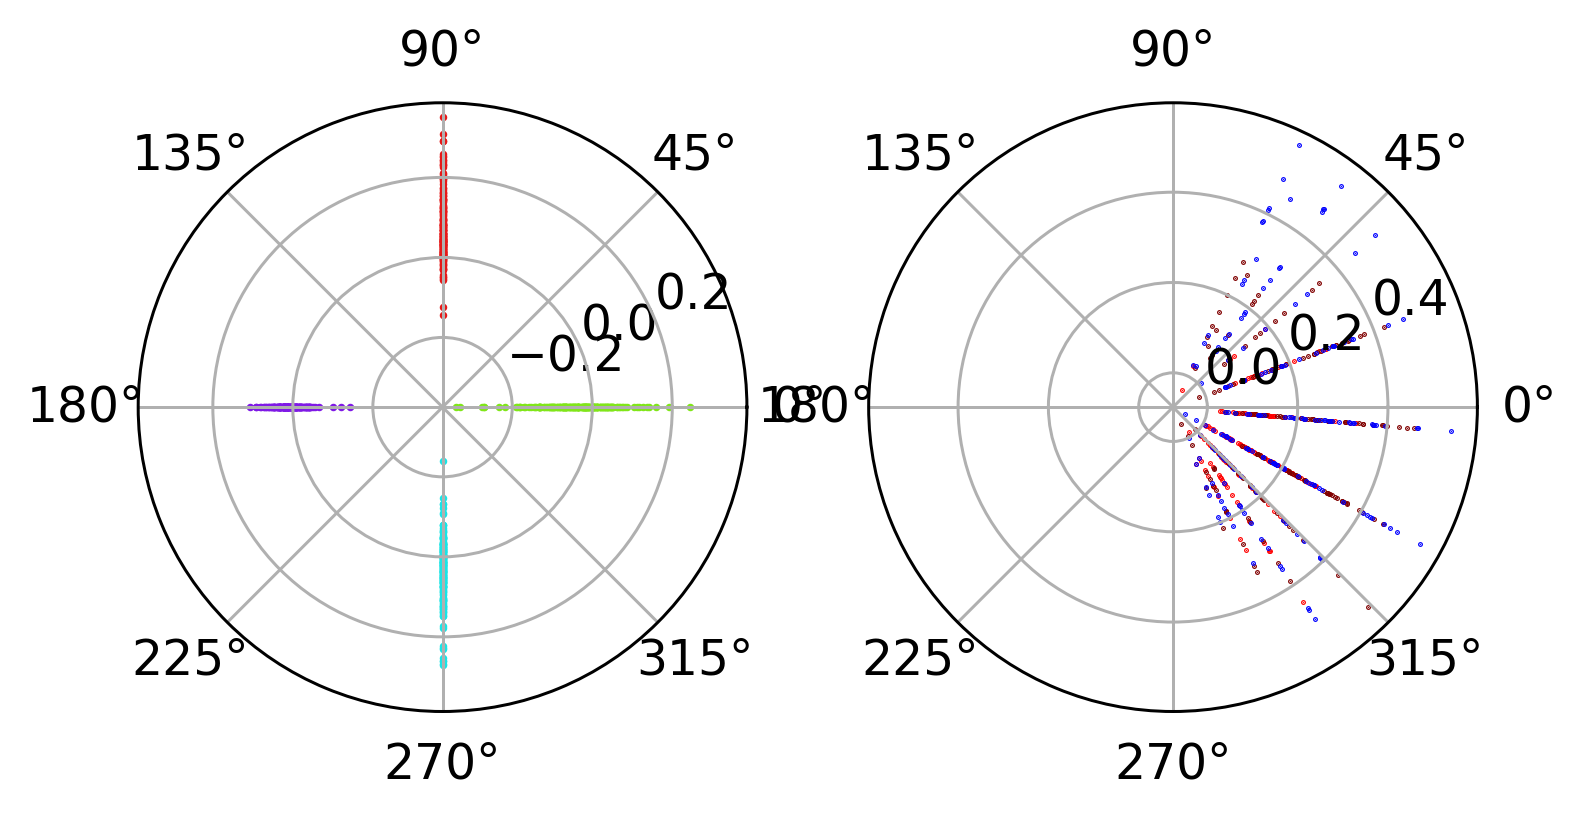

In [297]:
def fake_polar_xy(theta_deg, vals):
    """
    Convert polar (theta in degrees, radius=vals)
    to Cartesian (x, y) for a fake polar axis.
    """
    theta = np.deg2rad(theta_deg)
    vals = np.asarray(vals)

    x = vals * np.cos(theta)
    y = vals * np.sin(theta)

    return x, y

#create a simple rainbow plot
fig = plt.figure( dpi = 270)
ax = fig.add_subplot(121, projection='polar')
ax2 = fig.add_subplot(122, projection='polar')

omr_stim = ['forward', 'left', 'right', 'backward']
for stim in omr_stim:
    stim_df = fish.stimulus_df[fish.stimulus_df.stim_name == stim].iloc[0]
    stationary_time = stim_df['stationary_time']
    stationary_frame = int(stationary_time/fish.image_s)
    theta_deg = utils.omr_angles[stim]
    for n in barred_dot_neurons['dot_r']:
        vector = np.subtract(np.max(f_pertrial_dict[stim][trial_n, n, stationary_frame:].mean(axis = 0)), np.mean(f_pertrial_dict[stim][trial_n, n, :stationary_frame].mean(axis = 0)))
        ax.scatter(np.deg2rad(theta_deg), vector, color = utils.omr_colors[stim], s = 1)
        # for trial_n in range(f_pertrial_dict[stim].shape[0]):
        #     theta_deg = utils.omr_angles[stim]
        #     vector = np.subtract(np.max(f_pertrial_dict[stim][trial_n, n, stationary_frame:]), np.mean(f_pertrial_dict[stim][trial_n, n, :stationary_frame]))
        #     #x, y = fake_polar_xy(theta_deg, vector)
        #     #ax.scatter(x, y)
        #     ax.scatter(np.deg2rad(theta_deg), vector)

dot_stim = ['dot_r', str(['dot_r', 'right']), str(['dot_r', 'left'])]
for stim in dot_stim:
    stim_df = fish.stimulus_df[fish.stimulus_df.stim_name == stim].iloc[0]
    stationary_time = stim_df['stationary_time']
    if type(stationary_time) == list:
        stationary_time = stationary_time[0]
        if 'right' in stim:
            c = 'maroon'
        else:
            c = 'blue'
    else:
        c = utils.simple_dot_colors[stim]
    stationary_frame = int(stationary_time/fish.image_s)
    duration_time = stim_df['duration']
    duration_frame = int(duration_time/fish.image_s)
    _, _, stim_loc_scale, _= utils.get_dot_pos(stim_df, canvas_size = 1024, timescale = np.multiply(np.arange(0, f_pertrial_dict[stim].shape[2]), fish.image_s))
    for n in barred_dot_neurons['dot_r']:
        f_stim = f_pertrial_dict[stim][:, n, stationary_frame:duration_frame].mean(axis = 0)
        theta_deg = stim_loc_scale[np.argmax(np.diff(f_stim)) + stationary_frame]
        vector = np.subtract(np.max(f_stim), np.mean(f_pertrial_dict[stim][:, n, :stationary_frame].mean(axis = 0)))#find which frame post stim it responses
        ax2.scatter(np.deg2rad(theta_deg), vector, color = c, s = .1)
        # for trial_n in range(f_pertrial_dict[stim].shape[0]):
        #     theta_deg = stim_loc_scale[np.argmax(np.diff(f_pertrial_dict[stim][trial_n, n, stationary_frame:duration_frame])) + stationary_frame]
        #     vector = np.subtract(np.max(f_pertrial_dict[stim][trial_n, n, stationary_frame:]), np.mean(f_pertrial_dict[stim][trial_n, n, :stationary_frame]))#find which frame post stim it responses
        #     ax2.scatter(np.deg2rad(theta_deg), vector, color = utils.simple_dot_colors[stim])


In [287]:
stim_list

['dot_l',
 'dot_r',
 'forward',
 "['dot_l', 'forward']",
 "['dot_r', 'forward']",
 'left',
 "['dot_l', 'left']",
 "['dot_r', 'left']",
 'right',
 "['dot_l', 'right']",
 "['dot_r', 'right']",
 'backward',
 "['dot_l', 'backward']",
 "['dot_r', 'backward']"]

In [288]:
str(['dot_r', 'right'])

"['dot_r', 'right']"

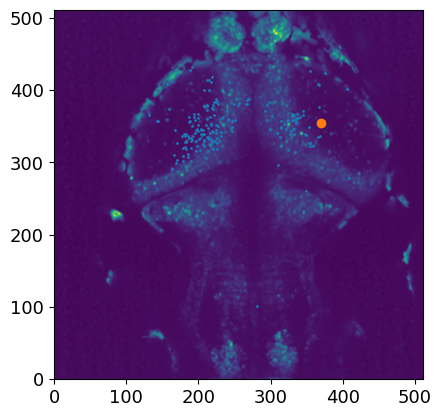

In [274]:
plt.imshow(fish.img_dict[1], origin = 'lower')
plt.scatter(fish.pos_all.loc[barred_dot_neurons['dot_l'], 'xpos'], fish.pos_all.loc[barred_dot_neurons['dot_l'], 'ypos'], s = 1)
plt.scatter(fish.pos_all.loc[n, 'xpos'], fish.pos_all.loc[n, 'ypos'])

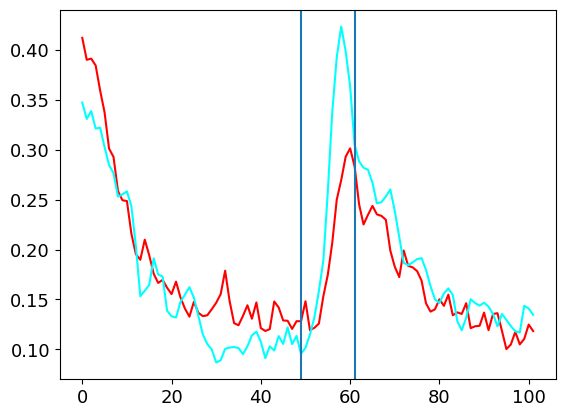

In [278]:
# [plt.plot(f_pertrial_dict['dot_r'][t, n, :], color = utils.simple_dot_colors['dot_r']) for t in range(10)]
# [plt.plot(f_pertrial_dict['dot_l'][t, n, :], color = utils.simple_dot_colors['dot_l']) for t in range(10)]
plt.plot(f_pertrial_dict['dot_r'][:, n, :].mean(axis = 0), color = utils.simple_dot_colors['dot_r'])
plt.plot(f_pertrial_dict['dot_l'][:, n, :].mean(axis = 0), color = utils.simple_dot_colors['dot_l'])
plt.axvline(stationary_frame)
plt.axvline(duration_frame)

In [77]:

[plt.plot(f_pertrial_dict['dot_l'][t, n, :], color = utils.simple_dot_colors['dot_l']) for t in range(10)]
np.argmax(f_pertrial_dict[stim][trial_n, n, stationary_frame:])

50

In [45]:
utils.dot_angles

{'l': 270, 'r': 90}

In [17]:
utils.omr_angles

{'forward': 0,
 'left': 270,
 'right': 90,
 'backward': 180,
 'forward_left': 315,
 'forward_right': 45,
 'backward_left': 225,
 'backward_right': 135,
 'medial_left': 270,
 'lateral_left': 270,
 'medial_right': 90,
 'lateral_right': 90,
 'converging': 0,
 'diverging': 0,
 'forward_backward': 0,
 'backward_forward': 0,
 'x_forward': 0,
 'x_backward': 180,
 'forward_x': 0,
 'backward_x': 180,
 'cw': 90,
 'ccw': 270}